# Zadanie 2: Czyszczenie i analiza zamówień 
## Generowanie danych

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Ustawienie ziarna losowości
np.random.seed(42)

n = 500
klienci = ["Anna Kowalska", "  Jan Nowak", "Anna Kowalska", "PIOTR WIŚNIEWSKI",
           "katarzyna lewandowska", "Tomasz Zieliński ", "Marta Wójcik",
           "anna kowalska ", "Krzysztof Kamiński", " Magdalena Dąbrowska"]
produkty = ["Laptop", "Mysz", "Klawiatura", "Monitor", "laptop", "MYSZ",
            "Słuchawki", "Pendrive", "monitor", "Webcam"]
kategorie = ["Elektronika", "elektronika", "ELEKTRONIKA", "Akcesoria",
             "akcesoria", "Akcesoria "]
miasta = ["Warszawa", "Kraków", "warszawa", "Gdańsk", "WROCŁAW",
          "Poznań", "Łódź ", " Warszawa", "kraków"]

# Generowanie losowych dat
start_date = datetime(2025, 1, 1)
daty_iso = [(start_date + timedelta(days=int(d))).strftime("%Y-%m-%d")
            for d in np.random.randint(0, 300, n // 2)]
daty_pl = [(start_date + timedelta(days=int(d))).strftime("%d.%m.%Y")
           for d in np.random.randint(0, 300, n // 2)]
daty = daty_iso + daty_pl
np.random.shuffle(daty)

# Tworzenie DataFrame z danymi
df = pd.DataFrame({
    "order_id": range(1001, 1001 + n),
    "klient": np.random.choice(klienci, n),
    "produkt": np.random.choice(produkty, n),
    "kategoria": np.random.choice(kategorie, n),
    "miasto": np.random.choice(miasta, n),
    "ilosc": np.random.choice([1, 2, 3, 5, -1, 0], n, p=[0.5, 0.2, 0.15, 0.1, 0.025, 0.025]),
    "cena_jednostkowa": np.random.choice(
        ["199.99", "299,99", "1 499.00", "89.50", "2999", "399.00 zł", None, "abc"],
        n
    ),
    "data_zamowienia": daty,
    "email": np.random.choice(
        ["anna@gmail.com", "JAN@WP.PL", "piotr.w@onet", "marta@gmail.com",
         "tomasz@interia.pl", None, "krzysztof.k@gmail.com", "brak"],
        n
    )
})

# Celowe psucie danych: wprowadzamy braki
for col in ["miasto", "kategoria", "data_zamowienia"]:
    df.loc[df.sample(frac=0.05, random_state=1).index, col] = np.nan

# Wprowadzanie duplikatów
df = pd.concat([df, df.sample(20, random_state=2)], ignore_index=True)

# Zapis do pliku
df.to_csv("zamowienia_messy.csv", index=False)
print(f"Wygenerowano plik 'zamowienia_messy.csv' — {len(df)} wierszy")


Wygenerowano plik 'zamowienia_messy.csv' — 520 wierszy


## Część 1 — Eksploracja danych
Wczytanie zbioru i wstępna weryfikacja pod kątem błędów.

In [2]:
# Wczytanie zabrudzonych danych
df_messy = pd.read_csv("zamowienia_messy.csv")

# Sprawdzenie rozmiaru i braków
print("Kształt zbioru:", df_messy.shape)
print("\n--- INFO ---")
df_messy.info()
print("\n--- BRAKI DANYCH ---")
print(df_messy.isnull().sum())

# Podgląd kategorii
print("\n--- KATEGORIE ---")
print(df_messy['kategoria'].value_counts(dropna=False))


Kształt zbioru: (520, 9)

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   order_id          520 non-null    int64
 1   klient            520 non-null    str  
 2   produkt           520 non-null    str  
 3   kategoria         495 non-null    str  
 4   miasto            495 non-null    str  
 5   ilosc             520 non-null    int64
 6   cena_jednostkowa  457 non-null    str  
 7   data_zamowienia   495 non-null    str  
 8   email             457 non-null    str  
dtypes: int64(2), str(7)
memory usage: 36.7 KB

--- BRAKI DANYCH ---
order_id             0
klient               0
produkt              0
kategoria           25
miasto              25
ilosc                0
cena_jednostkowa    63
data_zamowienia     25
email               63
dtype: int64

--- KATEGORIE ---
kategoria
Akcesoria      90
akcesoria      90
elektronika    87
A

### Znalezione problemy:
1. **Duplikaty:** Obecne powielone wiersze.
2. **Niespójne teksty:** Różna wielkość liter, zbędne spacje.
3. **Błędne typy:** Daty i ceny zapisane w różnych formatach jako tekst.
4. **Braki danych:** Wartości `NaN` m.in. w miastach i datach.
5. **Niepoprawne wartości:** Ilości <= 0 lub niepoprawne formaty e-mail.

## Część 2 — Czyszczenie

In [3]:
df_clean = df_messy.copy()

# 1. Usunięcie duplikatów
df_clean = df_clean.drop_duplicates()

# 2. Ujednolicenie tekstów (usunięcie spacji, format title/lower)
for col in ["klient", "produkt", "miasto"]:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
df_clean["kategoria"] = df_clean["kategoria"].astype(str).str.strip().str.lower()

# Naprawa wartości 'nan' powstałych z rzutowania teksów na np.nan
for col in ["klient", "produkt", "miasto", "kategoria"]:
    df_clean.loc[df_clean[col].isin(['Nan', 'nan']), col] = np.nan

# 3. Parsowanie dat (różne formaty) do datetime
df_clean["data_zamowienia"] = pd.to_datetime(df_clean["data_zamowienia"], format='mixed', dayfirst=True)

# 4. Konwersja cen na float (usunięcie waluty, spacji i zmiana na kropki)
df_clean["cena_jednostkowa"] = (
    df_clean["cena_jednostkowa"]
    .astype(str)
    .str.replace(" zł", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.replace(",", ".", regex=False)
)
df_clean["cena_jednostkowa"] = pd.to_numeric(df_clean["cena_jednostkowa"], errors="coerce")

# 5. Obsługa braków (usunięcie krytycznych, wypełnienie pozostałych)
df_clean = df_clean.dropna(subset=["cena_jednostkowa", "data_zamowienia"])
df_clean["miasto"] = df_clean["miasto"].fillna("unknown")
df_clean["kategoria"] = df_clean["kategoria"].fillna("unknown")
df_clean["email"] = df_clean["email"].fillna("brak_emaila")

# 6. Odfiltrowanie błędnych ilości
df_clean = df_clean[df_clean["ilosc"] > 0]

print("Rozmiar po wyczyszczeniu:", df_clean.shape)


Rozmiar po wyczyszczeniu: (339, 9)


## Część 3 — Transformacje

In [4]:
# Wyliczenie całkowitej wartości zamówienia
df_clean["wartosc_zamowienia"] = df_clean["ilosc"] * df_clean["cena_jednostkowa"]

# Wyciągnięcie atrybutów z daty
df_clean["rok"] = df_clean["data_zamowienia"].dt.year
df_clean["miesiac"] = df_clean["data_zamowienia"].dt.month
df_clean["nazwa_dnia"] = df_clean["data_zamowienia"].dt.day_name()

# Walidacja adresów e-mail przy pomocy regex
wzorzec_email = r"^[\w\.-]+@[\w\.-]+\.\w+$"
df_clean["email_poprawny"] = df_clean["email"].str.match(wzorzec_email).fillna(False)

df_clean.head()


,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email,wartosc_zamowienia,rok,miesiac,nazwa_dnia,email_poprawny
0,1001,Jan Nowak,Mysz,akcesoria,Kraków,2,199.99,2025-06-13,brak_emaila,399.98,2025,6,Friday,False
1,1002,Anna Kowalska,Monitor,elektronika,Kraków,1,399.00,2025-09-04,marta@gmail.com,399.00,2025,9,Thursday,True
4,1005,Piotr Wiśniewski,Mysz,elektronika,Gdańsk,1,1499.00,2025-05-02,anna@gmail.com,1499.00,2025,5,Friday,True
5,1006,Magdalena Dąbrowska,Laptop,akcesoria,Warszawa,1,299.99,2025-07-04,tomasz@interia.pl,299.99,2025,7,Friday,True
6,1007,Katarzyna Lewandowska,Monitor,akcesoria,Łódź,1,1499.00,2025-11-10,marta@gmail.com,1499.00,2025,11,Monday,True


## Część 4 — Analiza SQL-style

In [5]:
# Agregacja sprzedaży po miesiącach
wartosc_miesiace = df_clean.groupby("miesiac")["wartosc_zamowienia"].sum().reset_index()
print("--- Łączna wartość zamówień w każdym miesiącu ---")
display(wartosc_miesiace)

# Ranking Top 5 najlepszych klientów
top_klienci = (
    df_clean.groupby("klient")["wartosc_zamowienia"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
print("\n--- Top 5 klientów ---")
display(top_klienci)

# Średnia wartość zamówienia w podziale na kategorie
srednia_kategoria = df_clean.groupby("kategoria")["wartosc_zamowienia"].mean().reset_index()
print("\n--- Średnia wartość zamówienia w kategorii ---")
display(srednia_kategoria)


--- Łączna wartość zamówień w każdym miesiącu ---


,miesiac,wartosc_zamowienia
0,1,37647.27
1,2,72291.23
2,3,41308.83
3,4,92243.28
4,5,36691.80
5,6,53054.15
6,7,32045.28
7,8,58515.27
8,9,78498.32
9,10,38447.32



--- Top 5 klientów ---


,klient,wartosc_zamowienia
0,Anna Kowalska,203426.36
1,Krzysztof Kamiński,84677.82
2,Katarzyna Lewandowska,55083.04
3,Marta Wójcik,51070.25
4,Magdalena Dąbrowska,49000.33



--- Średnia wartość zamówienia w kategorii ---


,kategoria,wartosc_zamowienia
0,akcesoria,1671.656796
1,elektronika,1614.055696


## Część 5 — Wizualizacja

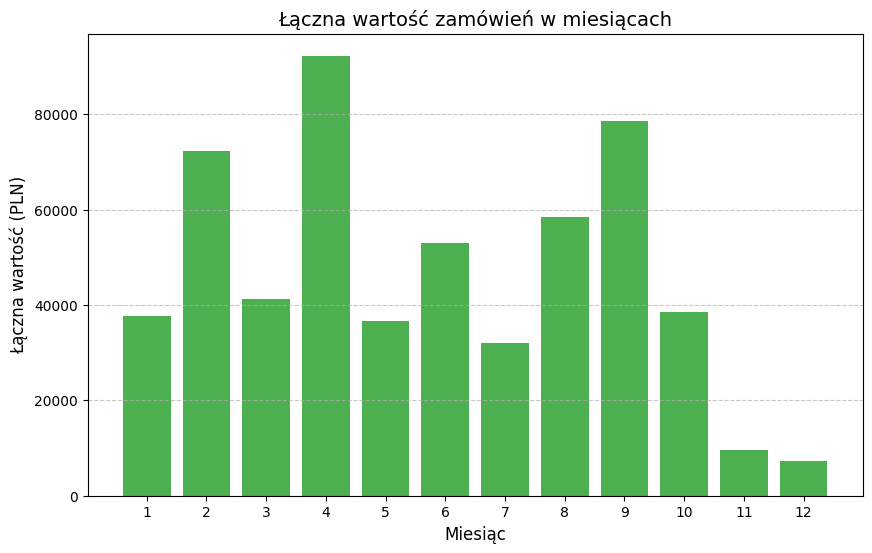

In [6]:
import matplotlib.pyplot as plt

# Wykres słupkowy sprzedaży w miesiącach
plt.figure(figsize=(10, 6))
plt.bar(wartosc_miesiace["miesiac"].astype(str), wartosc_miesiace["wartosc_zamowienia"], color="#4CAF50")
plt.title("Łączna wartość zamówień w miesiącach", fontsize=14)
plt.xlabel("Miesiąc", fontsize=12)
plt.ylabel("Łączna wartość (PLN)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


## Część 6 — Zapis

In [7]:
# Eksport oczyszczonych danych do CSV
df_clean.to_csv("zamowienia_clean.csv", index=False)
print("Dane zapisano do pliku 'zamowienia_clean.csv'.")


Dane zapisano do pliku 'zamowienia_clean.csv'.
